In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [3]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
# Fix missing values
df = df.dropna(subset=['embarked', 'embark_town'])
df['age'] = df['age'].fillna(df['age'].median())
df['deck_known'] = df['deck'].notna().astype(int)
df = df.drop(columns=['deck'])

df.isnull().sum()  # confirm all zeros

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
deck_known     0
dtype: int64

In [5]:
df['survived'].value_counts()

survived
0    549
1    340
Name: count, dtype: int64

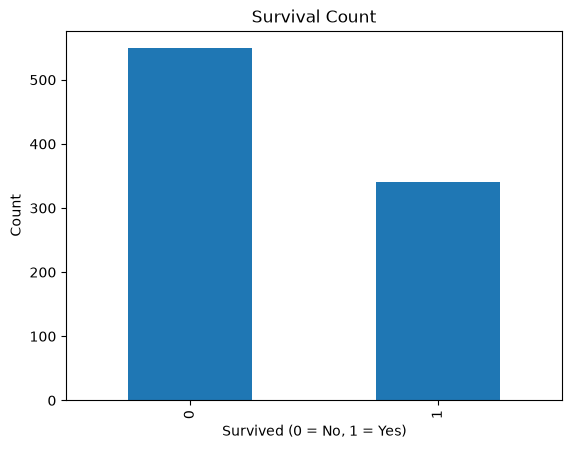

In [6]:
df['survived'].value_counts().plot(kind='bar')
plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

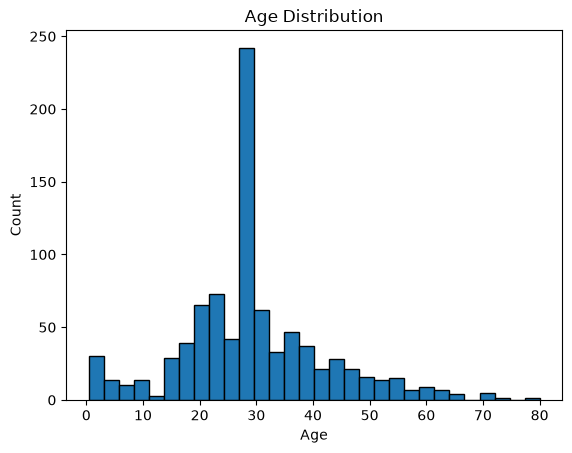

In [7]:
df['age'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

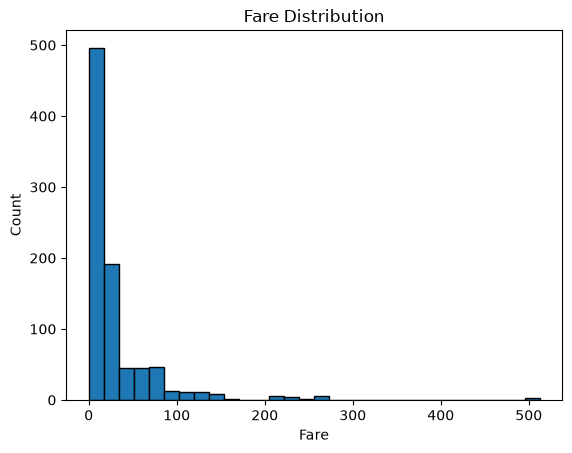

In [8]:
df['fare'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()

In [9]:
df.groupby('pclass')['survived'].mean()

pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64

In [10]:
df.groupby('sex')['survived'].mean()

sex
female    0.740385
male      0.188908
Name: survived, dtype: float64

In [11]:
df.groupby(['pclass', 'sex'])['survived'].mean()

pclass  sex   
1       female    0.967391
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: survived, dtype: float64

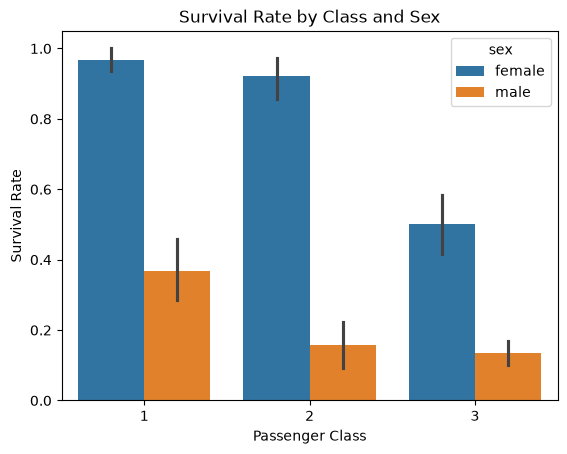

In [12]:
sns.barplot(data=df, x='pclass', y='survived', hue='sex')
plt.title('Survival Rate by Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

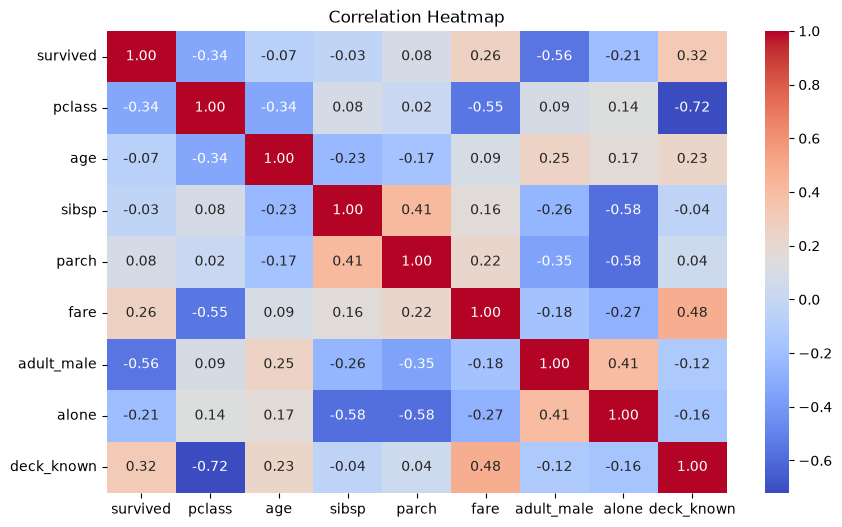

In [13]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=['int64', 'float64', 'bool'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Key Findings

I explored the Titanic dataset to understand what factors influenced passenger survival. Here's what stood out:

**1. Most passengers didn't survive.** Out of 891 passengers, only about 38% survived (549 died vs 340 survived) — so the dataset itself is a bit imbalanced, which is something to keep in mind if I ever build a model on this later.

**2. Money mattered — a lot.** Survival rate dropped sharply by class: 62.6% in 1st class, down to just 24.2% in 3rd class. Wealthier passengers were more than twice as likely to survive.

**3. But sex mattered even more.** Women survived at 74.0%, compared to just 18.9% for men — a bigger gap than the one caused by class.

**4. Sex actually beat class.** A woman in 3rd class (50.0% survival) had better odds than a man in 1st class (36.9%). Even with less money, being a woman mattered more for survival than being wealthy.

**5. Missing cabin data told its own story.** ~77% of the deck column was missing, so I turned it into a deck_known flag instead of guessing values. It correlated strongly with class (-0.72) — 1st class passengers were far more likely to have their cabin logged.

**Overall:** survival on the Titanic wasn't random — it followed a clear pattern shaped by both class and sex, with sex being the stronger factor of the two.